# LDA(線性判別分析)降維實驗:一步步手刻

**這份筆記在做什麼?**

LDA(Linear Discriminant Analysis)是一種**有監督**的降維方法:
它利用**類別標籤**來找投影方向,目標是投影之後 ——

- **同一類的點盡量擠在一起**(類內散佈小)
- **不同類的中心離得越遠越好**(類間散佈大)

本實驗用鳶尾花資料(4 維特徵 → 2 維),**全程手刻**每一個步驟,最後再用 sklearn 對答案。

**學習地圖(也是 LDA 的計算流程):**

| 步驟 | 主題 | 做什麼 |
|:---:|---|---|
| 1 | 資料準備 | 讀取 iris、標籤轉數字 |
| 2 | 均值向量 $m_i$ | 每一類在各特徵上的平均 |
| 3 | 散佈矩陣 | 類內 $S_W$、類間 $S_B$ 兩個 4×4 矩陣 |
| 4 | 特徵值分解 | 解 $S_W^{-1}S_B$,挑出最重要的投影方向 |
| 5 | 降維與視覺化 | 投影到 2 維,對比 sklearn 結果 |

> 💡 請**由上往下依序執行**每個 cell(Shift + Enter)。

## 1. 資料準備

### 1.1 讀取資料

讀入鳶尾花資料集:150 筆、4 個特徵、3 個品種。優先讀本地檔案,找不到就從 UCI 網站下載
(注意 `header=None`:原始檔第一列就是資料,不是欄名):

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

np.set_printoptions(precision=4)   # numpy 顯示 4 位小數,輸出比較整齊

# 自己來定義列名
feature_dict = {i: label for i, label in zip(
                range(4),
                  ('sepal length in cm',
                  'sepal width in cm',
                  'petal length in cm',
                  'petal wid in cm', ))}

label_dict = {i: label for i, label in zip(
                range(1, 4),
                  ('Setosa',
                  'Versicolor',
                  'Virginica'
                 ))}

# 資料讀取:優先用本地檔,沒有的話再從 UCI 下載
local_iris = Path('../PCA/iris.data')
data_src = local_iris if local_iris.exists() else \
    'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.io.parsers.read_csv(
    filepath_or_buffer=data_src,
    header=None,      # 原始檔沒有欄名列
    sep=',',
    )
# 指定列名
df.columns = [l for i, l in sorted(feature_dict.items())] + ['class label']

df.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal wid in cm,class label
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


整個資料集就是一個 150×4 的特徵矩陣 $X$,加上 150 個品種標籤 $y$:

<img src="1.png" alt="FAO" width="690" align="left">

### 1.2 標籤轉成數字

品種名稱是字串,先用 `LabelEncoder` 轉成數字(這裡 +1,讓三類對應 1、2、3):

In [2]:
from sklearn.preprocessing import LabelEncoder

X = df[['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal wid in cm']].values
y = df['class label'].values

# 製作標籤 {1: 'Setosa', 2: 'Versicolor', 3: 'Virginica'}
enc = LabelEncoder()
label_encoder = enc.fit(y)
y = label_encoder.transform(y) + 1

<img src="2.png" alt="FAO" width="290" align="left">

## 2. 分別求三種鳶尾花資料在不同特徵維度上的均值向量 $m_i$

LDA 的一切計算都從「每一類的中心在哪」開始:對每個類別,把它的樣本在 4 個特徵上各取平均,
得到一個 4 維均值向量:

<img src="3.png" alt="FAO" width="390">

In [3]:
# 這裏會保存所有的均值
mean_vectors = []
# 要計算 3 個類別
for cl in range(1, 4):
    # 求當前類別各個特徵的均值
    mean_vectors.append(np.mean(X[y == cl], axis=0))
    print('均值類別 %s: %s\n' % (cl, mean_vectors[cl-1]))

均值類別 1: [5.006 3.418 1.464 0.244]

均值類別 2: [5.936 2.77  4.26  1.326]

均值類別 3: [6.588 2.974 5.552 2.026]



三個類別的「中心」各不相同(尤其花瓣長度:1.46 → 4.26 → 5.55)—— LDA 要放大的正是這種差異。

## 3. 計算兩個 4×4 矩陣:類內散佈矩陣和類間散佈矩陣

### 3.1 類內散佈矩陣 $S_W$(within-class)

衡量「**每一類自己內部**有多分散」:每個樣本減去自己類別的均值,做外積後全部加總 ——
LDA 希望投影後這個量**越小越好**(同類擠在一起):

<img src="5.png" alt="FAO" width="330">

In [4]:
# 原始數據中有 4 個特徵
S_W = np.zeros((4, 4))
# 要考慮不同類別,自己算自己的
for cl, mv in zip(range(1, 4), mean_vectors):
    class_sc_mat = np.zeros((4, 4))
    # 選中屬於當前類別的數據
    for row in X[y == cl]:
        # 這裏相當於對各個特徵分別進行計算,用矩陣的形式
        row, mv = row.reshape(4, 1), mv.reshape(4, 1)
        # 跟公式一樣:(x - m_i)(x - m_i)^T 逐筆累加
        class_sc_mat += (row - mv).dot((row - mv).T)
    S_W += class_sc_mat
print('類內散佈矩陣:\n', S_W)

類內散佈矩陣:
 [[38.9562 13.683  24.614   5.6556]
 [13.683  17.035   8.12    4.9132]
 [24.614   8.12   27.22    6.2536]
 [ 5.6556  4.9132  6.2536  6.1756]]


### 3.2 類間散佈矩陣 $S_B$(between-class)

衡量「**類別中心之間**離得多開」:每類均值 $m_i$ 減去全局均值 $m$ 做外積,
再乘上該類的樣本數 $N_i$ 加總 —— LDA 希望投影後這個量**越大越好**(異類拉開距離):

<img src="6.png" alt="FAO" width="430">

In [5]:
# 全局均值
overall_mean = np.mean(X, axis=0)
# 構建類間散佈矩陣
S_B = np.zeros((4, 4))
# 對各個類別進行計算
for i, mean_vec in enumerate(mean_vectors):
    # 當前類別的樣本數
    n = X[y == i+1, :].shape[0]
    mean_vec = mean_vec.reshape(4, 1)
    overall_mean = overall_mean.reshape(4, 1)
    # 如上述公式進行計算:N_i * (m_i - m)(m_i - m)^T
    S_B += n * (mean_vec - overall_mean).dot((mean_vec - overall_mean).T)

print('類間散佈矩陣:\n', S_B)

類間散佈矩陣:
 [[ 63.2121 -19.534  165.1647  71.3631]
 [-19.534   10.9776 -56.0552 -22.4924]
 [165.1647 -56.0552 436.6437 186.9081]
 [ 71.3631 -22.4924 186.9081  80.6041]]


## 4. 求解投影方向:特徵值分解

「類間大、類內小」兩個目標合成一個比值,最佳投影方向就是矩陣 $S_W^{-1}S_B$ 的**特徵向量**:

<img src="7.png" alt="FAO" width="230">

In [6]:
# 求解矩陣的特徵值、特徵向量
eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
# 拿到每一個特徵值和其所對應的特徵向量
for i in range(len(eig_vals)):
    eigvec_sc = eig_vecs[:, i].reshape(4, 1)
    print('\n特徵向量 {}: \n{}'.format(i+1, eigvec_sc.real))
    print('特徵值 {:}: {:.2e}'.format(i+1, eig_vals[i].real))


特徵向量 1: 
[[ 0.2049]
 [ 0.3871]
 [-0.5465]
 [-0.7138]]
特徵值 1: 3.23e+01

特徵向量 2: 
[[-0.009 ]
 [-0.589 ]
 [ 0.2543]
 [-0.767 ]]
特徵值 2: 2.78e-01

特徵向量 3: 
[[-0.8817]
 [ 0.2649]
 [ 0.2335]
 [ 0.313 ]]
特徵值 3: -4.47e-16

特徵向量 4: 
[[ 0.0625]
 [-0.3572]
 [-0.4246]
 [ 0.8296]]
特徵值 4: 6.24e-15


### 特徵值與特徵向量的意義

- **特徵向量**:表示映射(投影)的方向
- **特徵值**:表示該方向的重要程度(能把類別分多開)

把它們配成對、按特徵值大小排序:

In [7]:
# 特徵值和特徵向量配對
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) for i in range(len(eig_vals))]

# 按特徵值大小進行排序
eig_pairs = sorted(eig_pairs, key=lambda k: k[0], reverse=True)

print('特徵值排序結果:\n')
for i in eig_pairs:
    print(i[0])

特徵值排序結果:

32.27195779972981
0.27756686384004325
6.23737019826058e-15
4.474147710541176e-16


In [8]:
print('特徵值佔總體百分比:\n')
eigv_sum = sum(eig_vals)
for i, j in enumerate(eig_pairs):
    print('特徵值 {0:}: {1:.2%}'.format(i+1, (j[0]/eigv_sum).real))

特徵值佔總體百分比:

特徵值 1: 99.15%
特徵值 2: 0.85%
特徵值 3: 0.00%
特徵值 4: 0.00%


**觀察結果:**

- 第 1 個方向就佔了 **99.15%** 的判別能力,第 2 個只剩 0.85%
- 第 3、4 個特徵值是 $10^{-15}$ 等級 —— 那是數值誤差,**實際上就是 0**。
  這不是巧合:**k 個類別的 LDA 最多只有 k−1 個有效方向**(3 類 → 最多 2 維),
  所以 iris 用 LDA 降到 2 維,幾乎不損失判別資訊

### 選擇前兩維,組成投影矩陣 W

In [9]:
W = np.hstack((eig_pairs[0][1].reshape(4, 1), eig_pairs[1][1].reshape(4, 1)))
print('矩陣W:\n', W.real)

矩陣W:
 [[ 0.2049 -0.009 ]
 [ 0.3871 -0.589 ]
 [-0.5465  0.2543]
 [-0.7138 -0.767 ]]


In [10]:
# 執行降維操作:150×4 的 X 乘上 4×2 的 W → 150×2
X_lda = X.dot(W)
X_lda.shape

(150, 2)

## 5. 視覺化:降維前 vs 降維後

寫一個通用的散點圖函式,先看**原始資料**(只取前兩個特徵 —— 也就是「不動腦的降維」):

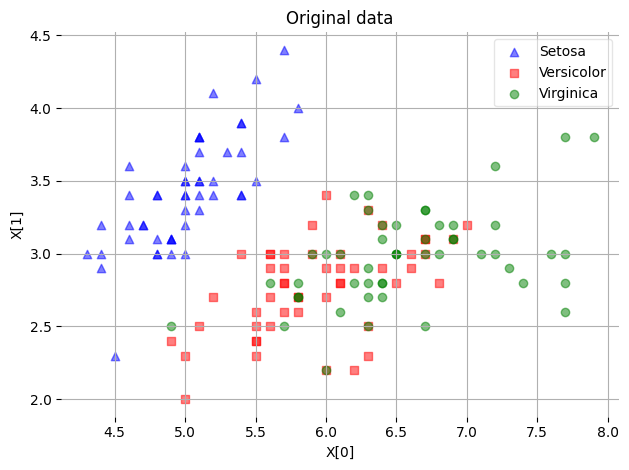

In [11]:
from matplotlib import pyplot as plt
%matplotlib inline

def plot_lda_scatter(data, xlabel, ylabel, title):
    '''把 150×2 的資料按三個類別畫成散點圖'''
    ax = plt.subplot(111)
    for label, marker, color in zip(
            range(1, 4), ('^', 's', 'o'), ('blue', 'red', 'green')):
        plt.scatter(x=data[:, 0].real[y == label],
                    y=data[:, 1].real[y == label],
                    marker=marker,
                    color=color,
                    alpha=0.5,
                    label=label_dict[label])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    leg = plt.legend(loc='upper right', fancybox=True)
    leg.get_frame().set_alpha(0.5)
    plt.title(title)
    # 隱藏外框,讓圖乾淨一點
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.grid()
    plt.tight_layout()
    plt.show()

plot_lda_scatter(X, 'X[0]', 'X[1]', 'Original data')

原始資料只看前兩個特徵時,**紅色(Versicolor)和綠色(Virginica)混在一起**,分不乾淨。

再看 LDA 找到的兩個方向:

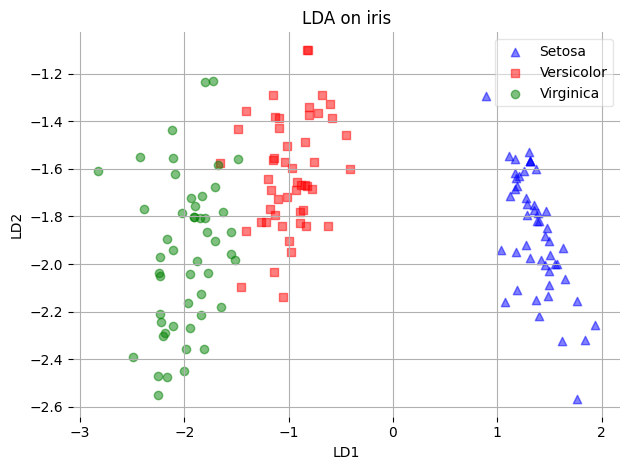

In [12]:
plot_lda_scatter(X_lda, 'LD1', 'LD2', 'LDA on iris')

**觀察結果:** 投影到 LDA 方向後,三類沿著 **LD1 軸**幾乎完全分開 ——
和 99.15% 的特徵值佔比呼應:判別資訊幾乎都在第一個方向上。

## 6. 用 sklearn 對答案

手刻走完全程了,實務上一行搞定:

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# LDA
sklearn_lda = LDA(n_components=2)
X_lda_sklearn = sklearn_lda.fit_transform(X, y)

In [14]:
def plot_scikit_lda(X, title):
    '''畫 sklearn LDA 的投影結果(y 軸乘 -1 翻轉,方便和手刻結果對照)'''
    ax = plt.subplot(111)
    for label, marker, color in zip(
            range(1, 4), ('^', 's', 'o'), ('blue', 'red', 'green')):
        plt.scatter(x=X[:, 0][y == label],
                    y=X[:, 1][y == label] * -1,   # 翻轉圖形,方向對齊手刻版
                    marker=marker,
                    color=color,
                    alpha=0.5,
                    label=label_dict[label])
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    leg = plt.legend(loc='upper right', fancybox=True)
    leg.get_frame().set_alpha(0.5)
    plt.title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    plt.grid()
    plt.tight_layout()
    plt.show()

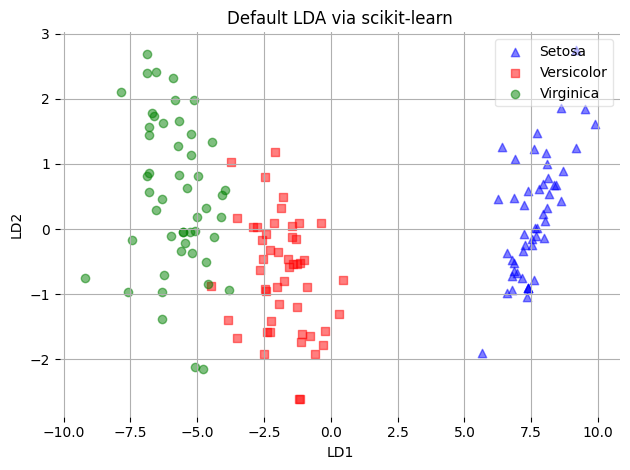

In [15]:
plot_scikit_lda(X_lda_sklearn, title='Default LDA via scikit-learn')

**觀察結果:** 和手刻版的圖形結構一致(三類同樣沿 LD1 分開)。
座標的正負方向或縮放可能不同 —— **特徵向量整體乘上 −1 或縮放仍是同一個方向**,
所以程式裡把 y 軸翻轉只是為了方便對照,不影響任何資訊。

## 總結:這份實驗的重點整理

| # | 重點 |
|:---:|---|
| 1 | LDA 是**有監督**降維:目標 = 投影後「**類內散佈小、類間散佈大**」 |
| 2 | 計算流程:各類均值 $m_i$ → 類內 $S_W$、類間 $S_B$ → 解 $S_W^{-1}S_B$ 的特徵值/向量 |
| 3 | **特徵向量 = 投影方向,特徵值 = 該方向的判別重要性**;按特徵值挑前 k 維 |
| 4 | k 類最多只有 **k−1 個有效方向**(iris 3 類 → 2 維,佔比 99.15% + 0.85%) |
| 5 | 降維 = 一次矩陣乘法 $X \cdot W$;sklearn 的 `LinearDiscriminantAnalysis` 一行等效 |
| 6 | 對照:**PCA 無監督、找變異最大的方向;LDA 有監督、找類別分最開的方向** |

**多做實驗,得出結果!!!**